In [ ]:
#Kaan Algür - GAN
#21.12.2025

Active Device: cpu
Upload dataset
Data processed. Total spam messages: 1368
Training starting..
Epoch [10/200] | D Loss: 1.0736 | G Loss: 1.2290
Epoch [20/200] | D Loss: 1.1841 | G Loss: 0.9316
Epoch [30/200] | D Loss: 1.2264 | G Loss: 0.8423
Epoch [40/200] | D Loss: 1.3800 | G Loss: 0.7231
Epoch [50/200] | D Loss: 1.2817 | G Loss: 0.8490
Epoch [60/200] | D Loss: 1.2681 | G Loss: 0.8604
Epoch [70/200] | D Loss: 1.4158 | G Loss: 0.8330
Epoch [80/200] | D Loss: 1.3178 | G Loss: 0.7497
Epoch [90/200] | D Loss: 1.2151 | G Loss: 0.7877
Epoch [100/200] | D Loss: 1.3398 | G Loss: 0.7783
Epoch [110/200] | D Loss: 1.2452 | G Loss: 0.8048
Epoch [120/200] | D Loss: 1.2856 | G Loss: 0.8244
Epoch [130/200] | D Loss: 1.2888 | G Loss: 0.8212
Epoch [140/200] | D Loss: 1.2972 | G Loss: 0.8600
Epoch [150/200] | D Loss: 1.3067 | G Loss: 0.9244
Epoch [160/200] | D Loss: 1.2533 | G Loss: 0.8092
Epoch [170/200] | D Loss: 1.2092 | G Loss: 0.9190
Epoch [180/200] | D Loss: 1.1382 | G Loss: 0.9320
Epoch [190/20

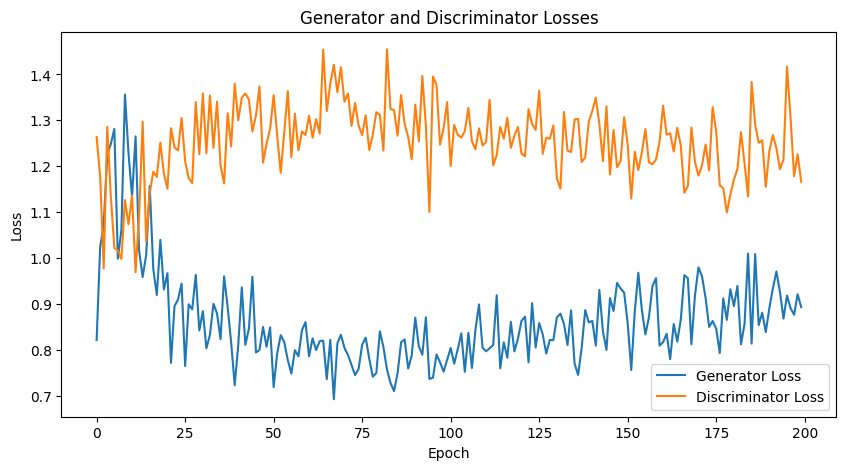


--- Sample Spam Emails Generated ---
Sample 1: their payment enable stream formats company purposes by real ready advice without under company that out fixed also ability is adobe production we if how are the s sell subject
Sample 2: by thinkgeek be times we list content failure later test in have of you and all i delivery report board choose mailing gas secret not s free macromedia here results
Sample 3: and customer before to be people this us for to for with to news and logo website s legal below with deliver your all com of with competitors
Sample 4: life fact and has to or for from cialls american cd these for more that that from e are c news com transaction i my barry deposit why here publication
Sample 5: be the as and or in will and and our am would and company you need is it idea more a don the to trust soft before email
Sample 6: just people bring government order with us better by clear sale card access an thinking may of know your are in de of e are i of homesite your are


In [1]:
#libraries import
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

# Hyperparameters
NOISE_DIM = 100
SEQ_LEN = 30
BATCH_SIZE = 32
LR_G = 0.0001
LR_D = 0.0004
EPOCHS = 200

# 2. PREPROCESSING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Upload Dataset
try:
    df = pd.read_csv('emails.csv')
    print("Upload dataset")
except FileNotFoundError:
    print("ERROR: The file 'emails.csv' could not be found.")
    df = pd.DataFrame({'text': ['spam email sample', 'click here'], 'spam': [1, 1]})

# Only SPAM emails
if 'spam' in df.columns:
    spam_df = df[df['spam'] == 1].copy()
elif 'label_num' in df.columns:
    spam_df = df[df['label_num'] == 1].copy()
else:
    spam_df = df.copy()

spam_df['clean_text'] = spam_df['text'].apply(clean_text)

# Tokenization
all_words = " ".join(spam_df['clean_text']).split()
word_counts = Counter(all_words)
vocab = sorted(word_counts, key=word_counts.get, reverse=True)[:1500]
word_to_idx = {word: i+1 for i, word in enumerate(vocab)}
idx_to_word = {i+1: word for i, word in enumerate(vocab)}
idx_to_word[0] = ""

#Converts text into a fixed-length numerical vector
def text_to_vector(text):
    tokens = text.split()
    vector = [word_to_idx.get(token, 0) for token in tokens]
    if len(vector) < SEQ_LEN:
        vector += [0] * (SEQ_LEN - len(vector))
    else:
        vector = vector[:SEQ_LEN]
    return vector

data_vectors = [text_to_vector(t) for t in spam_df['clean_text']]
data_vectors = np.array(data_vectors, dtype=np.float32)

# NORMALIZATION
vocab_size = len(word_to_idx) + 1
# Normalize to range [-1, 1] for GAN stability
data_normalized = (data_vectors / (vocab_size - 1)) * 2 - 1
# Create PyTorch dataset and dataloader
dataset = TensorDataset(torch.tensor(data_normalized).to(device))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Data processed. Total spam messages: {len(data_vectors)}")

# 3. IMPROVED MODEL ARCHITECTURE
class Generator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),  # Batch Normalization
            nn.ReLU(),
            nn.Dropout(0.3),  # Dropout
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, output_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),  # Dropout
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
# Move models to device
generator = Generator(NOISE_DIM, SEQ_LEN).to(device)
discriminator = Discriminator(SEQ_LEN).to(device)

# Different learning rates
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))

# 4. IMPROVED TRAINING LOOP
G_losses = []
D_losses = []

print("Training starting..")

for epoch in range(EPOCHS):
    for real_vectors in dataloader:
        real_vectors = real_vectors[0]
        batch_size = real_vectors.size(0)

        # Label smoothing
        real_labels = torch.ones(batch_size, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(device) + 0.1

        # === Discriminator Training ===
        # 1. Real data
        outputs = discriminator(real_vectors)
        d_loss_real = criterion(outputs, real_labels)

        # 2. Fake data
        noise = torch.randn(batch_size, NOISE_DIM).to(device)
        fake_vectors = generator(noise)
        outputs = discriminator(fake_vectors.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # === Generator Training ===
        noise = torch.randn(batch_size, NOISE_DIM).to(device)
        fake_vectors = generator(noise)
        outputs = discriminator(fake_vectors)

        g_loss = criterion(outputs, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    G_losses.append(g_loss.item())
    D_losses.append(d_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

# 5. RESULTS
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.title("Generator and Discriminator Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

def decode_vector(vector):
    vector = vector.cpu().detach().numpy()
    denormalized = ((vector + 1) / 2) * (vocab_size - 1)
    indices = np.round(denormalized).astype(int)

    words = []
    for idx in indices:
        idx = max(0, min(idx, vocab_size - 1))
        word = idx_to_word.get(idx, "")
        if word:
            words.append(word)
    return " ".join(words)

print("\n--- Sample Spam Emails Generated ---")
generator.eval()
with torch.no_grad():
    noise = torch.randn(15, NOISE_DIM).to(device)
    generated_vectors = generator(noise)

    for i, vec in enumerate(generated_vectors):
        text = decode_vector(vec)
        print(f"Sample {i+1}: {text}")

In [2]:
# Save the loss graph
plt.savefig('loss_curves.png', dpi=300, bbox_inches='tight')
print("Graph saved!")

Graph saved!


<Figure size 640x480 with 0 Axes>

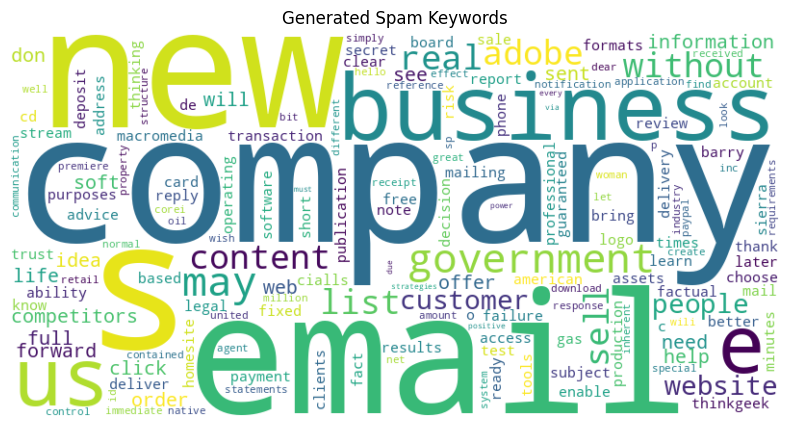

In [3]:
from wordcloud import WordCloud

all_generated = " ".join([decode_vector(vec) for vec in generated_vectors])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_generated)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Generated Spam Keywords')
plt.show()